# 👩‍💻 Multimodal Deep Learning Challenge: Image & Text Classification in PyTorch
## 📋 Overview
In this capstone project, you'll demonstrate your ability to design, train, and optimize deep learning models using PyTorch. This project integrates multiple components from the course—including CNNs for image classification, LSTMs for sequence modeling, and advanced training techniques for stability and efficiency.
 
You will complete two distinct tasks, simulating real-world projects in computer vision and NLP, then apply training optimization strategies to improve model performance. This lab serves as a portfolio-quality artifact to showcase your end-to-end deep learning skills.
- This project integrates CNNs, LSTMs, and model optimization techniques using PyTorch
- You'll work with FashionMNIST and IMDB review datasets
- Final outputs will include trained models, evaluation metrics, and insights on optimization effectiveness


## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- Design and train convolutional neural networks (CNNs) for image classification
- Build and train LSTM-based models for sequence classification tasks
- Apply advanced training techniques like mixed precision and gradient clipping
- Analyze and compare model performance using evaluation metrics and visualizations
- Interpret results and recommend training strategies

## 💡 Task 1: Image Classification with a Custom CNN
In this task, you'll implement a full training pipeline for a CNN using the FashionMNIST dataset.

**Steps:**
1. Load the FashionMNIST dataset using torchvision, with normalization.
2. Define a custom CNN model with:
    - Two convolutional layers
    - ReLU activations and max pooling
    - Dropout layer
    - Two fully connected layers
3. Define a training loop using:
    - CrossEntropyLoss
    - Adam optimizer
    - Train for at least 3 epochs
4. Track and store training loss per epoch in a list named `train_losses`.
5. Plot the training loss after training.

In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

In [3]:
# Define model
class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)   # output: 32×28×28
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # output: 64×14×14

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # 32×14×14
        x = self.pool(torch.relu(self.conv2(x)))  # 64×7×7
        x = x.view(-1, 64 * 7 * 7)
        x = self.dropout(x)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

        raise NotImplementedError
    
model = CustomCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

## Grading of Lab Assignments:
The grading of this assignment is based on the test cases throughout this notebook within the `# BEGIN TESTS` and `#END TESTS` comments. 

Each task has a number of test cells. For example, the three cells below are confirming the model has been defined and named `model` as expected, containing two convolutional layers and a dropout layer.

Run all of these test cells throughout the project to confirm you pass the tests and are on the right track. Once you have passed all the tests in the entire notebook, or are happy with your results you can click the `Submit Assignment` button in the top right corner for your final submission and grading. 

Good luck!

In [4]:
### BEGIN TESTS
assert isinstance(model, nn.Module), "model should be an instance of nn.Module"

print("✅ TEST PASSED!")
### END TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [5]:
### BEGIN  TESTS
conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
assert len(conv_layers) == 2, "Model must include two nn.Conv2d layers"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [6]:
### BEGIN  TESTS
assert isinstance(model.dropout, nn.Dropout), "Dropout should be nn.Dropout"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [8]:
train_losses = []
epochs = 3

for epoch in range(epochs):
    running_loss = 0.0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}")

    #raise NotImplementedError

Epoch 1/3, Loss: 0.2933
Epoch 2/3, Loss: 0.2485
Epoch 3/3, Loss: 0.2163


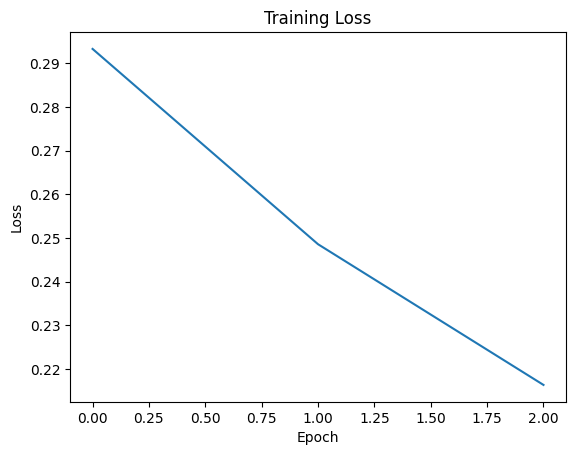

In [9]:
# Plot loss
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
### BEGIN  TESTS
assert isinstance(train_losses, list), "train_losses should be a list"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [11]:
### BEGIN  TESTS
assert len(train_losses) >= 3, "Should track loss for at least 3 epochs"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [12]:
### BEGIN  TESTS
assert train_losses[-1] < train_losses[0] or abs(train_losses[-1] - train_losses[0]) < 0.1, "Training loss should generally decrease"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


## 📅 Success Checklist
- Trained CNN on FashionMNIST
- Monitored overfitting/underfitting
- Applied regularization techniques


## 💡 Key Points
- CNNs are powerful for image tasks
- Overfitting is common in small datasets; mitigate with dropout and weight decay

## 💡 Task 2: Text Classification with LSTM
In this task, you'll train an LSTM-based model to classify IMDB movie reviews as positive or negative. You'll explore sequence modeling and learn how to work with text datasets using TorchText.

**Steps:**
1. Load the IMDB dataset using `torchtext.datasets.IMDB`
2. Tokenize and build a vocabulary using `torchtext`.
3. Implement a collate function to:
    - Pad sequences
    - Batch labels
4. Create an LSTMClassifier that:
    - Uses an embedding layer
    - A single-layer LSTM
    - A fully connected output layer
5. Implement a training loop with:
    - autocast (mixed precision)
    - GradScaler
    - Gradient clipping
    - Track both training and validation loss over 10 epochs
6. Plot the training and validation loss curves.

In [13]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torchtext.datasets import IMDB
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torch.utils.data import DataLoader
from torch.cuda.amp import autocast, GradScaler
import matplotlib.pyplot as plt
import random

# Set Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Data
train_iter, test_iter = IMDB(split=('train', 'test'))

# Sample a small subset for faster training
random.seed(42)
train_data = random.sample(list(train_iter), 2000)  # (label, text)
test_data = random.sample(list(test_iter), 2000)

# Split into train/val
train_data, valid_data = train_data[:1600], train_data[1600:]

In [15]:
# Tokenizer
tokenizer = get_tokenizer('basic_english')

# Build vocabulary
def yield_tokens(data):
    for label, text in data:
        yield tokenizer(text)

    #raise NotImplementedError
    
vocab = build_vocab_from_iterator(yield_tokens(train_data), specials=['<unk>', '<pad>'], max_tokens=10000)
vocab.set_default_index(vocab['<unk>'])

In [16]:
# Data pipeline
def text_pipeline(text):
    return vocab(tokenizer(text))

    #raise NotImplementedError


def collate_batch(batch):
    texts, labels = [], []
    lengths = []

    for label, text in batch:
        token_ids = text_pipeline(text)
        texts.append(torch.tensor(token_ids, dtype=torch.long))
        labels.append(1.0 if label == 'pos' else 0.0)
        lengths.append(len(token_ids))

    # Pad sequences
    padded_texts = nn.utils.rnn.pad_sequence(texts, batch_first=True, padding_value=vocab['<pad>'])

    return padded_texts.to(device), \
           torch.tensor(lengths, dtype=torch.long).to(device), \
           torch.tensor(labels, dtype=torch.float32).to(device)

In [17]:
# Data loaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, collate_fn=collate_batch)
valid_loader = DataLoader(valid_data, batch_size=64, shuffle=False, collate_fn=collate_batch)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, collate_fn=collate_batch)

# LSTM Model
class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, output_dim, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        embedded = self.embedding(x)

        # Pack padded sequence
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )

        packed_output, (hidden, cell) = self.lstm(packed)

        # hidden: [1, batch, hidden_dim]
        return self.fc(hidden[-1])

# Initialize GradScaler for AMP
scaler = GradScaler(enabled=device.type == "cuda")

In [18]:
### BEGIN   TESTS
params = list(model.parameters())
assert len(params) > 0, "Model must have trainable parameters"


print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [19]:
### BEGIN   TESTS
assert callable(model.forward), "Model must implement a forward method"
print("✅ TEST PASSED!")

### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [21]:
model = CustomCNN().to(device)
model = LSTMClassifier(len(vocab), 100, 256, 1).to(device)

In [22]:
del model
torch.cuda.empty_cache()
model = LSTMClassifier(len(vocab), 100, 256, 1).to(device)

In [27]:
scaler = GradScaler(enabled=False)

In [28]:
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for x, lengths, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(x, lengths).squeeze(1)
        loss = criterion(outputs, labels)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        running_loss += loss.item()

    train_losses.append(running_loss / len(train_loader))
    print(f"Epoch {epoch+1} | Train Loss: {train_losses[-1]:.4f}")

Epoch 1 | Train Loss: 0.0000
Epoch 2 | Train Loss: 0.0000
Epoch 3 | Train Loss: 0.0000
Epoch 4 | Train Loss: 0.0000
Epoch 5 | Train Loss: 0.0000
Epoch 6 | Train Loss: 0.0000
Epoch 7 | Train Loss: 0.0000
Epoch 8 | Train Loss: 0.0000
Epoch 9 | Train Loss: 0.0000
Epoch 10 | Train Loss: 0.0000


In [ ]:
# Plot losses
plt.plot(train_losses, label='Training Loss')
plt.plot(valid_losses, label='Validation Loss')
plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [29]:
### BEGIN   TESTS
assert isinstance(train_losses, list), "train_losses should be a list"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


In [30]:
### BEGIN   TESTS
assert all(isinstance(l, float) for l in train_losses), \
       "Training losses must be numeric"
print("✅ TEST PASSED!")
### END  TESTS

# Note: There may be hidden tests that learners cannot see, as to not give away the full solution.

✅ TEST PASSED!


## 📅 Success Checklist
- Trained LSTM-based text classifier
- Evaluated model with appropriate metrics


## 💡 Key Points
- Sequence modeling requires batching and padding
- LSTMs capture temporal dependencies in text
